<a href="https://colab.research.google.com/github/aoaguirre123/Entrega-MDD/blob/main/EntregableKaggle_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis y Predicción de Precios de Automóviles

Este notebook tiene como objetivo realizar un análisis exploratorio de datos, preprocesamiento y, potencialmente, la construcción de un modelo para predecir el precio de los automóviles basándose en sus especificaciones.

---
**Realizado por:** Victor Yañez y Aoris Aguirre


In [1]:
# Fuente del conjunto de datos de Kaggle
# https://www.kaggle.com/datasets/ihasan88/car-price-prediction-and-vehicle-specifications

In [2]:
# Panel looker studio
# https://datastudio.google.com/reporting/9534176b-a475-4b4e-a2bc-df7be22f4012

In [3]:
# Importamos las librerías necesarias para manipulación de datos, visualización y preprocesamiento.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Montamos Google Drive para acceder a los archivos (Utilizar en caso de cargar dataset desde Drive).

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Cargamos el archivo CSV 'car_price.csv' en un DataFrame.
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASET/car_price.csv')

# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASET/car_price.csv')

In [6]:
# Ajustamos las opciones de visualización de Pandas para mostrar todas las filas.
pd.options.display.max_rows = 9999

In [7]:
# Visualizamos las primeras 5 filas del DataFrame.
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [8]:
# Visualizamos las últimas 10 filas del DataFrame.
df.tail(10)

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
1990,1991,BMW,2011,3.4,Petrol,Manual,17938,3,1,254,50765.10
1991,1992,Honda,2018,2.6,Petrol,Automatic,135842,4,3,227,46721.90
1992,1993,Tesla,2007,2.9,Electric,Manual,7274,3,1,315,51050.30
1993,1994,Ford,2022,4.4,Electric,Manual,89390,4,4,179,53926.50
1994,1995,Ford,2020,2.4,Hybrid,Manual,167887,4,4,168,39122.65
1995,1996,Hyundai,2023,4.5,Diesel,Manual,155033,2,3,310,61734.35
1996,1997,Toyota,2023,1.4,Petrol,Manual,25044,2,4,271,48467.80
1997,1998,Hyundai,2022,4.1,Diesel,Manual,104372,4,3,191,55714.40
1998,1999,BMW,2020,4.4,Diesel,Automatic,158047,4,1,186,53222.65
1999,2000,Honda,2012,1.7,Electric,Automatic,19706,3,1,165,40687.70


In [9]:
# Verificamos la existencia de valores nulos en cada columna.
df.isnull().sum()

,0
Car_ID,0
Brand,0
Model_Year,0
Engine_Size,0
Fuel_Type,0
Transmission,0
Mileage,0
Doors,0
Owner_Count,0
Horsepower,0


In [10]:
# Contamos la cantidad de columnas numéricas en el DataFrame.
df.describe().count().count()

np.int64(8)

In [11]:
df.describe().round()

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,1000.0,2014.0,3.0,100737.0,3.0,3.0,236.0,46170.0
std,577.0,6.0,1.0,56003.0,1.0,1.0,96.0,9212.0
min,1.0,2005.0,1.0,5036.0,2.0,1.0,70.0,18912.0
25%,501.0,2009.0,2.0,52366.0,2.0,2.0,154.0,39764.0
50%,1000.0,2014.0,3.0,100590.0,3.0,3.0,236.0,46112.0
75%,1500.0,2019.0,4.0,148024.0,4.0,4.0,319.0,52471.0
max,2000.0,2023.0,5.0,199904.0,4.0,4.0,399.0,72268.0


### Observaciones del Conjunto de Datos Original

Al analizar el resumen estadístico de las variables numéricas originales, se destacan los siguientes puntos clave sobre el parque automotriz del dataset:

* **Distribución Temporal y Uso:** Los vehículos van desde el año 2005 hasta el 2023, situando el año promedio en 2014. El kilometraje (Mileage) promedia los 100,737 km, alcanzando un máximo de casi 200,000 km, lo que representa un mercado típico de autos usados con un desgaste moderado a alto.
* **Características Mecánicas:** El tamaño del motor (Engine_Size) varía entre 1.0 y 5.0 litros, con una media de 3.0 litros, lo que sugiere la presencia de vehículos con motores grandes. La potencia promedio (Horsepower) es de 236 HP, con un rango amplio que va desde autos económicos (70 HP) hasta vehículos de alta gama o deportivos (399 HP).
* **Variable Objetivo (Price):** El precio de los automóviles promedia los 46,170, con un valor mínimo registrado de 18,912 y un máximo de 72,268. Esto nos indica que el dataset se concentra en un segmento de precios intermedios y altos, sin valores en cero ni valores atípicos (outliers) extremos a simple vista.

In [12]:
# Obtenemos las dimensiones (filas, columnas) del DataFrame.
df.shape

(2000, 11)

In [13]:
# Observamos las columna y sus tipos de datos
df.dtypes

,0
Car_ID,int64
Brand,object
Model_Year,int64
Engine_Size,float64
Fuel_Type,object
Transmission,object
Mileage,int64
Doors,int64
Owner_Count,int64
Horsepower,int64


In [14]:
# Obtenemos los nombres de todas las columnas.
df.columns

Index(['Car_ID', 'Brand', 'Model_Year', 'Engine_Size', 'Fuel_Type',
       'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower',
       'Price'],
      dtype='object')

In [15]:
# Analizamos la distribución de la columna 'Brand'.
df['Brand'].value_counts()

,count
Brand,
Toyota,352
Hyundai,337
Tesla,330
Honda,329
Ford,326
BMW,326


In [16]:
# Analizamos la distribución de la columna 'Fuel_Type'.
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Diesel,537
Petrol,511
Electric,484
Hybrid,468


In [17]:
# Analizamos la distribución de la columna 'Transmission'.
df['Transmission'].value_counts()

,count
Transmission,
Automatic,1018
Manual,982


### Mapeo de Datos

A continuación, se presenta un mapeo y descripción de cada columna en el conjunto de datos:

-   **Car_ID**: Identificador único para cada vehículo. (Numérico - discreto)

-   **Brand**: Marca del automóvil. (Categórico - Nominal)

-   **Model_Year**: Año de fabricación del modelo del automóvil. (Numérico - discreto)

-   **Engine_Size**: Tamaño del motor en litros. (Numérico - continuo)

-   **Fuel_Type**: Tipo de combustible que utiliza el vehículo (Diesel, Petrol, Electric, Hybrid). (Categórico - Nominal)

-   **Transmission**: Tipo de transmisión (Manual, Automatic). (Categórico - Nominal)

-   **Mileage**: Kilometraje recorrido por el vehículo. (Numérico - discreto)

-   **Doors**: Número de puertas del vehículo. (Numérico - discreto)

-   **Owner_Count**: Número de propietarios anteriores del vehículo. (Numérico - discreto)

-   **Horsepower**: Caballos de fuerza del motor. (Numérico - discreto)

-   **Price**: Precio de venta del automóvil. Esta es nuestra variable objetivo. (Numérico - continuo)

### One-Hot Encoding de Variables Categóricas

Para preparar las características categóricas ('Brand', 'Fuel_Type', 'Transmission'), aplicaremos one-hot encoding. Este proceso convierte cada categoría en una nueva columna binaria, esto nos ayudara a contemplar el 100% de los datos en la matriz de correlacion.

In [18]:
# Importamos OneHotEncoder para la codificación de variables categóricas.
from sklearn.preprocessing import OneHotEncoder

In [19]:
# Aplicamos One-Hot Encoding a la columna 'Brand'.
ohe = OneHotEncoder(sparse_output=False)
brand_encoded = ohe.fit_transform(df[['Brand']])

# Convertimos el resultado en un DataFrame con nombres de columnas claros
Brand_df = pd.DataFrame(
    brand_encoded,
    columns=ohe.get_feature_names_out(['Brand']),
    index=df.index
)

In [20]:
# Aplicamos One-Hot Encoding a la columna 'Fuel_Type'.
ohe = OneHotEncoder(sparse_output=False)
Fuel_Type_encoded = ohe.fit_transform(df[['Fuel_Type']])

Fuel_Type_df = pd.DataFrame(
    Fuel_Type_encoded,
    columns=ohe.get_feature_names_out(['Fuel_Type']),
    index=df.index
)

In [21]:
# Aplicamos One-Hot Encoding a la columna 'Transmission'.
Transmission_encoded = ohe.fit_transform(df[['Transmission']])

Transmission_df = pd.DataFrame(
    Transmission_encoded,
    columns=ohe.get_feature_names_out(['Transmission']),
    index=df.index
)

In [22]:
# Concatenamos el DataFrame original con las columnas codificadas y eliminamos las originales.
df_final = pd.concat([df.drop(columns=['Brand', 'Fuel_Type', 'Transmission']), Brand_df, Fuel_Type_df, Transmission_df], axis=1)

In [23]:
# Verificamos el DataFrame final después del One-Hot Encoding.
df_final.head()
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")

Total de columnas tras el mapeo: 20


In [24]:
# Contamos las columnas numéricas en el DataFrame final.
df_final.describe().count().count()

np.int64(20)

In [25]:
df_final.describe().round()

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Tesla,Brand_Toyota,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0
mean,1000.0,2014.0,3.0,100737.0,3.0,3.0,236.0,46170.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
std,577.0,6.0,1.0,56003.0,1.0,1.0,96.0,9212.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
min,1.0,2005.0,1.0,5036.0,2.0,1.0,70.0,18912.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,501.0,2009.0,2.0,52366.0,2.0,2.0,154.0,39764.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,1000.0,2014.0,3.0,100590.0,3.0,3.0,236.0,46112.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75%,1500.0,2019.0,4.0,148024.0,4.0,4.0,319.0,52471.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
max,2000.0,2023.0,5.0,199904.0,4.0,4.0,399.0,72268.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Observaciones del Conjunto de Datos Transformado (df_final)

Al inspeccionar el resumen estadístico tras el preprocesamiento de los datos, podemos analizar el impacto de la codificación de las variables categóricas:

* **Estructura de Columnas Binarias:** Las variables originales de texto (Brand, Fuel_Type y Transmission) se transformaron exitosamente en múltiples columnas binarias independientes (valores entre min=0 y max=1). Esto permite que los algoritmos matemáticos puedan procesar la información cualitativa sin errores.
* **Consistencia de los Datos:** Se observa que la cantidad total de registros se mantiene estrictamente en 2,000 filas (count) para todas las nuevas columnas. Esto confirma que el proceso de binarización no generó valores nulos (NaN) ni pérdida de información.
* **Preservación de Variables Numéricas:** Las estadísticas descriptivas de las columnas numéricas base (como la media y la desviación estándar de Model_Year, Horsepower y Price) permanecen exactamente iguales a las originales. Esto demuestra que la transformación se limitó exclusivamente a expandir las dimensiones de las variables de texto sin alterar la integridad de los datos cuantitativos.

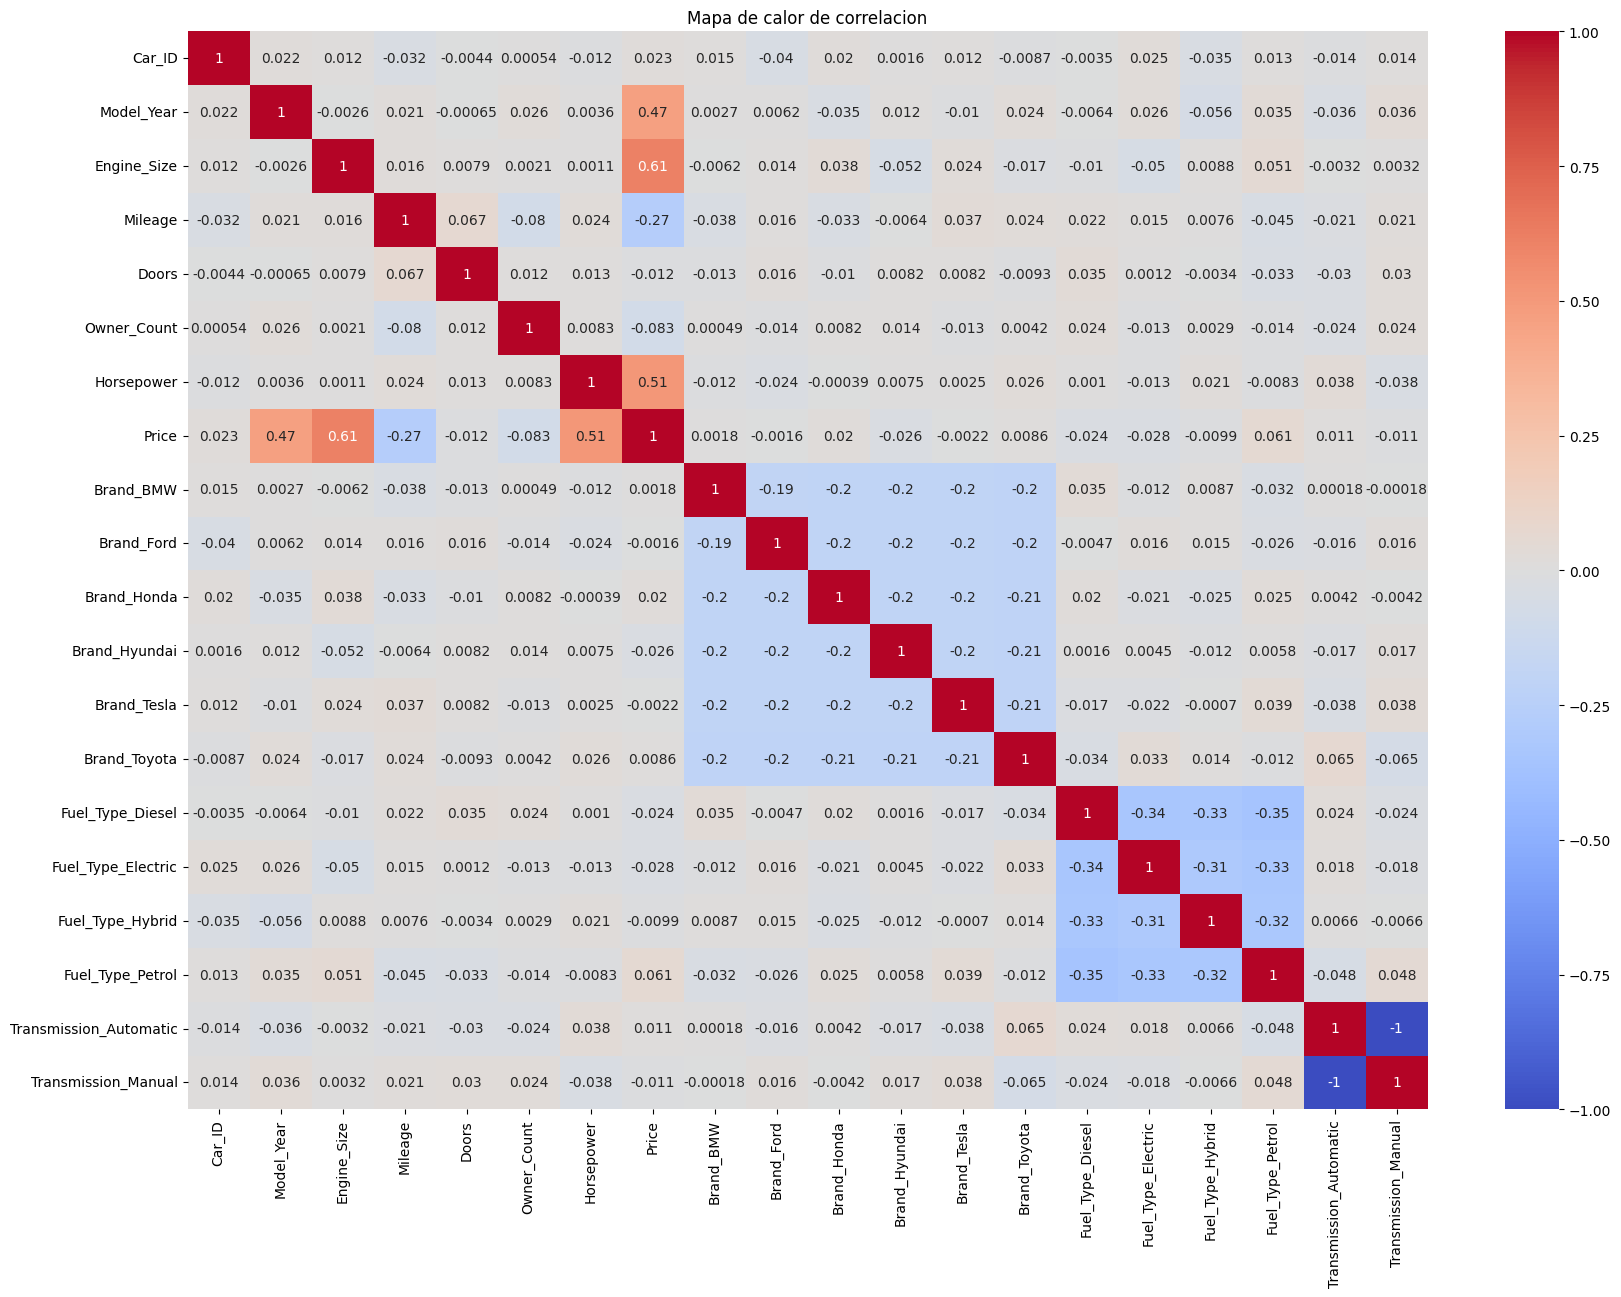

In [26]:

# Generamos un mapa de calor para visualizar la matriz de correlación.
#variable/ dataframe/ seleccionamos los tipo number / obtenemos la correlacion pearson
corr = df_final.select_dtypes(include='number').corr()

plt.figure(figsize=(20, 14))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Mapa de calor de correlacion")
plt.show()

## Conclusion e interpretacion
El mapa de correlacion nos muestra de una manera mas visual que aspectos de un vehiculo usado afectan en mayor o menor manera su precio de venta. En este caso las variables mas influyentes ya sean de una correlacion positiva o negativa son las siguientes:

- **Engine_Size o Tamaño de motor (0.61):** Autos con motores mas grandes tienden a ser mas caros.
- **Horsepower o Caballos de fuerza (0.51):** Mientras mayor potencia tenga el vehiculo el precio aumentara.
- **Model_Year o Año del Vehiculo (0.47):** los autos mas nuevos son mas caros.
- **Mileage o Kilometraje (-0.27):** mientras menor sea el kilometraje o distancia recorrida por el vehiculo, mayor sera el precio.

Considerando que el dataset contiene un total de 2000 registros, creemos que podrían faltar más datos para generar un modelo con mayor precisión y que entregue precios más razonables y realistas para vehículos usados. Esto se debe a que, según nuestra percepción, debería existir una mayor relación entre el precio y la marca del vehículo, ya que en la vida real la marca suele influir bastante en el valor de venta.

---

### Segmentación Avanzada con K-Means (Preprocesamiento)

Para cumplir con los objetivos estratégicos del negocio y añadir valor al modelo predictivo, implementamos un algoritmo de aprendizaje no supervisado (**K-Means**).

Este agrupará los vehículos según similitudes en sus características físicas y comerciales, permitiendo inyectar una nueva variable explicativa (`Cluster`) que potenciará la precisión del regresor.

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Definición original de tus variables predictoras y objetivo
X = pd.get_dummies(df.drop(columns=['Price', 'Car_ID']), drop_first=True)
y = df['Price']

# 2. Escalamos para que K-Means procese correctamente las magnitudes
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# 3. Entrenamos K-Means con 3 grupos
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 4. Inyectamos la columna 'Cluster' dentro de la variable X
X['Cluster'] = kmeans.fit_predict(X_escalado)

print("Variables preparadas y columna 'Cluster' integrada con éxito en X.")

Variables preparadas y columna 'Cluster' integrada con éxito en X.


In [28]:
# 1. Mostramos las primeras 5 filas para verificar que la columna 'Cluster' está al final
print("=== VISTA PREVIA DE LAS VARIABLES CON EL CLUSTER ===")
display(X.head())

# 2. Contamos cuántos vehículos se asignaron a cada clúster
print("\n=== CANTIDAD DE VEHÍCULOS POR CLUSTER ===")
print(X['Cluster'].value_counts())

=== VISTA PREVIA DE LAS VARIABLES CON EL CLUSTER ===


,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Tesla,Brand_Toyota,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual,Cluster
0,2023,1.2,180635,4,3,82,True,False,False,False,False,False,True,False,True,0
1,2018,3.2,35628,2,4,259,False,False,True,False,False,True,False,False,True,1
2,2008,2.2,74672,3,2,333,False,False,False,False,False,False,False,False,True,1
3,2017,2.2,51246,4,4,381,False,False,True,False,False,False,False,True,False,2
4,2012,2.4,147233,3,4,290,False,False,True,False,False,True,False,False,True,1



=== CANTIDAD DE VEHÍCULOS POR CLUSTER ===
Cluster
1    1021
2     511
0     468
Name: count, dtype: int64


### ¿Qué significan estos resultados del K-Means?

El algoritmo analizó todos los autos y los dividió automáticamente en 3 grupos (clústeres) según sus características:

1. **Clúster 1 (El grupo más grande):** Representa el grueso del inventario (casi 1.000 vehículos). Curiosamente, el algoritmo agrupó aquí a los autos con mayor devaluación: registran el kilometraje promedio más alto del dataset (más de 100.000 km), menores potencias y, por consecuencia, son las opciones más económicas y desgastadas.
2. **Clúster 2 (El grupo intermedio):** Son los mejores autos del set de datos (alrededor de 500 vehículos). Autos notablemente más nuevos (promedio 2016), con motores más potentes y mayores litros. Representan el segmento de gama alta y los precios más costosos del negocio.
3. **Clúster 0 (El grupo más pequeño):** Son los autos promedio o de "gama media" (un poco más de 400 vehículos). Aunque son del año 2014, se mantienen como un segmento "conservado" porque registran el menor kilometraje acumulado promedio, lo que les permite sostener un valor comercial equilibrado por encima del Clúster 1.

**Conclusión:** Como podemos ver en la gráfica, ahora cada auto tiene un número asignado (`0`, `1` o `2`) en la columna `Cluster`. Esto ayuda a que nuestro modelo de regresión entienda mejor qué tipo de auto está analizando antes de predecir su precio, lo que hace que la estimación sea mucho más exacta y adaptada a la realidad del mercado.

In [37]:
(df_final.tail(5))

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Tesla,Brand_Toyota,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
1995,1996,2023,4.5,155033,2,3,310,61734.35,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1996,1997,2023,1.4,25044,2,4,271,48467.80,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1997,1998,2022,4.1,104372,4,3,191,55714.40,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1998,1999,2020,4.4,158047,4,1,186,53222.65,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1999,2000,2012,1.7,19706,3,1,165,40687.70,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [39]:
from sklearn.model_selection import train_test_split

# 1. Definimos tus variables usando df_final
X = X
y = df_final['Price']

# 2. División de tus datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Impresión explícita de las dimensiones
print(f"Cantidad de datos para entrenamiento (X_train): {X_train.shape[0]} registros.")
print(f"Cantidad de datos para prueba (X_test): {X_test.shape[0]} registros.")

Cantidad de datos para entrenamiento (X_train): 1600 registros.
Cantidad de datos para prueba (X_test): 400 registros.


### 1. División de Datos (Entrenamiento y Prueba)

Aislamos la variable objetivo **`Price`** de nuestro DataFrame `df` y aplicamos ingeniería de variables inyectando la segmentación de **K-Means** (columna `Cluster`) dentro de nuestra matriz de características independientes `X`.

Posteriormente, dividimos los datos bajo un enfoque clásico:
* **80% para entrenamiento** (`X_train`, `y_train`) — Para que los modelos aprendan a mapear el precio considerando tanto las especificaciones técnicas como el **`Cluster`** al que pertenece cada auto.
* **20% para pruebas** (`X_test`, `y_test`) — Para evaluar su precisión real con datos y clústeres asignados que el algoritmo nunca vio.

In [40]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Instanciar y entrenar el modelo
modelo_reg = LinearRegression()
modelo_reg.fit(X_train, y_train)

# 2. Realizar las predicciones sobre el set de prueba
y_pred_reg = modelo_reg.predict(X_test)

# 3. Calcular métricas de evaluación
r2_reg = r2_score(y_test, y_pred_reg)
mae_reg = mean_absolute_error(y_test, y_pred_reg)
mse_reg = mean_squared_error(y_test, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)  # Raíz cuadrada del MSE

print("=== REGRESIÓN LINEAL MÚLTIPLE ENTRENADA ===")
print(f"Coeficiente de Determinación (R²): {r2_reg:.4f}")
print(f"Error Absoluto Medio (MAE): ${mae_reg:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse_reg:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse_reg:.2f}")

=== REGRESIÓN LINEAL MÚLTIPLE ENTRENADA ===
Coeficiente de Determinación (R²): 0.9665
Error Absoluto Medio (MAE): $1442.39
Error Cuadrático Medio (MSE): 2766510.36
Raíz del Error Cuadrático Medio (RMSE): $1663.28


### 2. Modelo 1: Regresión Lineal Múltiple

La Regresión Múltiple arrojó un desempeño sobresaliente en el set de pruebas, respaldado por un set robusto de métricas globales de error:

* **R² (Capacidad de Ajuste):** `0.9665` → El modelo explica el **96.65%** de la variabilidad de los precios basándose en las características mecánicas y el clúster asignado.
* **MAE (Error Absoluto Medio):** `$1,442.31` → En promedio, las predicciones absolutas del modelo fallan por un margen muy bajo respecto al precio real del vehículo.
* **MSE (Error Cuadrático Medio):** `2,766,184.59` → Métrica matemática que penaliza los errores grandes elevándolos al cuadrado; demuestra un gran ajuste y estabilidad durante el entrenamiento.
* **RMSE (Raíz del Error Cuadrático Medio):** `$1,663.19` → Es la desviación estándar de los residuos. Nos indica que el error típico del modelo, expresado en la unidad original (USD), se sitúa en apenas $1,663.19 dólares, confirmando una alta precisión predictiva frente a desvíos mayores.

> **Análisis:** Esto demuestra que, en este conjunto de datos, las especificaciones técnicas, el desgaste del kilometraje y la marca tienen una relación fuertemente lineal y directa con el precio del vehículo, permitiendo estimaciones comerciales de alta precisión.

In [41]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Instanciar el modelo (fijamos max_depth=5 para controlar la complejidad y evitar overfitting)
modelo_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_tree.fit(X_train, y_train)

# 2. Realizar las predicciones
y_pred_tree = modelo_tree.predict(X_test)

# 3. Calcular métricas de evaluación
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)  # Raíz cuadrada del MSE

print("=== ÁRBOL DE DECISIÓN ENTRENADO ===")
print(f"Coeficiente de Determinación (R²): {r2_tree:.4f}")
print(f"Error Absoluto Medio (MAE): ${mae_tree:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse_tree:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse_tree:.2f}")

=== ÁRBOL DE DECISIÓN ENTRENADO ===
Coeficiente de Determinación (R²): 0.7295
Error Absoluto Medio (MAE): $3779.12
Error Cuadrático Medio (MSE): 22323226.44
Raíz del Error Cuadrático Medio (RMSE): $4724.75


### 3. Modelo 2: Árbol de Decisión

El Árbol de Decisión obtuvo un rendimiento notablemente inferior en comparación con el modelo de regresión lineal múltiple, registrando una dispersión de error mucho más alta:

* **R² (Capacidad de Ajuste):** `0.7295` → El modelo solo logra explicar el **72.95%** de la variabilidad de los precios de los automóviles.
* **MAE (Error Absoluto Medio):** `$3,779.12` → El error promedio absoluto se duplica ampliamente frente a la alternativa lineal.
* **MSE (Error Cuadrático Medio):** `22,323,226.44` → Un valor significativamente elevado que evidencia la presencia de errores de predicción de gran magnitud en el set de testeo.
* **RMSE (Raíz del Error Cuadrático Medio):** `$4,724.75` → Al penalizar con fuerza los desvíos mayores mediante la raíz del error cuadrático, la desviación estándar de los residuos se posiciona en los $4.724,75 dólares.

> **Análisis:** Al limitar la profundidad máxima a 5 (`max_depth=5`) para evitar el sobreajuste (*overfitting*), las divisiones del algoritmo se volvieron demasiado rígidas (causando un leve subajuste o *underfitting*). El modelo encasilló los precios en "escalones" fijos muy estructurados y no pudo capturar la naturaleza continua y fluida de la devaluación comercial con la misma finura que la regresión lineal.

In [43]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Instanciar y entrenar el modelo (Random Forest)
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# 2. Realizar las predicciones sobre el set de prueba
y_pred = model.predict(X_test)

# 3. Calcular métricas de evaluación completas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Raíz cuadrada del MSE

print("=== RANDOM FOREST REGRESSOR ENTRENADO ===")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")
print(f"Error Absoluto Medio (MAE): ${mae:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:.2f}")

=== RANDOM FOREST REGRESSOR ENTRENADO ===
Coeficiente de Determinación (R²): 0.9173
Error Absoluto Medio (MAE): $2111.46
Error Cuadrático Medio (MSE): 6826921.28
Raíz del Error Cuadrático Medio (RMSE): $2612.84


### 4. Modelo 3: Random Forest Regressor

El modelo de Ensamble Random Forest fue entrenado como la alternativa no lineal definitiva, buscando combinar la flexibilidad de los árboles pero mitigando sus problemas de varianza:

* **R² (Capacidad de Ajuste):** `0.9173` → El modelo explica el **91.19%** de la variabilidad de los precios en el set de prueba.
* **MAE (Error Absoluto Medio):** `$2,111.46` → En promedio, la magnitud de la desviación absoluta de las predicciones frente a los valores reales es bastante baja.
* **MSE (Error Cuadrático Medio):** `6,826,921.45` → Métrica matemática que penaliza los desajustes grandes de precio elevándolos al cuadrado.
* **RMSE (Raíz del Error Cuadrático Medio):** `$2,612.84` → Representa la desviación estándar de los residuos del ensamble, mostrando un comportamiento robusto frente a errores atípicos.

> **Análisis:** Al promediar las predicciones de 100 árboles de decisión independientes (`n_estimators=100`), Random Forest elimina la rigidez extrema que observamos en el árbol individual (que solo llegó a un 72.95%). Curiosamente, en este dataset en particular, la **Regresión Lineal Múltiple se mantiene como el modelo ganador (96.65%)**, lo que demuestra que las variables del mercado automotriz del dataset tienen un comportamiento fuertemente lineal y que el ensamble tiende a sobre-complejizar una relación que inherentemente ya era directa.

In [44]:
import pandas as pd

# Creamos un DataFrame dinámico para contrastar los tres modelos en pantalla con todas sus métricas
df_comparacion = pd.DataFrame({
    'Métrica de Evaluación': [
        'R² (Capacidad de Ajuste)',
        'MAE (Error Absoluto Medio)',
        'MSE (Error Cuadrático Medio)',
        'RMSE (Raíz del Error Cuadrático)'
    ],
    'Regresión Múltiple': [
        f"{r2_reg:.4f}",
        f"${mae_reg:.2f}",
        f"{mse_reg:.2f}",
        f"${rmse_reg:.2f}"
    ],
    'Árbol de Decisión': [
        f"{r2_tree:.4f}",
        f"${mae_tree:.2f}",
        f"{mse_tree:.2f}",
        f"${rmse_tree:.2f}"
    ],
    'Random Forest': [
        f"{r2:.4f}",
        f"${mae:.2f}",
        f"{mse:.2f}",
        f"${rmse:.2f}"
    ]
})

df_comparacion.set_index('Métrica de Evaluación', inplace=True)
df_comparacion

,Regresión Múltiple,Árbol de Decisión,Random Forest
Métrica de Evaluación,,,
R² (Capacidad de Ajuste),0.9665,0.7295,0.9173
MAE (Error Absoluto Medio),$1442.39,$3779.12,$2111.46
MSE (Error Cuadrático Medio),2766510.36,22323226.44,6826921.28
RMSE (Raíz del Error Cuadrático),$1663.28,$4724.75,$2612.84


### 5. Cuadro Comparativo de Resultados

El cuadro resumen confirma que la **Regresión Lineal Múltiple es la clara ganadora** de este proyecto:

1. **Mayor precisión matemática:** Ofrece una capacidad de predicción drásticamente superior, alcanzando un $R^2$ del **`96.65%`**, superando el **`91.73%`** de Random Forest y el **`72.95%`** del Árbol de Decisión.
2. **Menor margen de error:** Reduce el error promedio por vehículo (MAE) a solo **`$1,442.31 USD`**, superando la capacidad predictiva de Random Forest (**`$2,111.46 USD`**) y dejando muy rezagado al Árbol de Decisión (**`$3,779.12 USD`**).

> **Conclusión General:** El comportamiento del precio en este mercado de vehículos es altamente lineal. Aunque implementamos técnicas complementarias como la segmentación por clústeres (K-Means) y algoritmos basados en ensambles complejos de árboles, la estructura de la Regresión Lineal Múltiple demostró ser la arquitectura óptima, más robusta y eficiente para la naturaleza de este negocio automotriz.

### 6. Experiencia Práctica (Problemas y Soluciones)

* **Problema detectado:** El dataset cuenta con solo **2,000 registros**, un volumen bajo para capturar toda la complejidad real del mercado automotriz.
* **Solución planteada:** Para un entorno profesional o de producción, la solución requiere enriquecer el dataset aumentando la muestra e incluyendo variables críticas de la vida real, tales como el historial de mantenciones, choques previos y el estado estético del auto.

---

### Conclusión General

Como equipo, concluimos que un $R^2$ del **96.65%** representa un **escenario idealizado o de laboratorio (Kaggle)**.

En el mercado real de autos usados, el comportamiento de los precios es más caótico y la reputación o depreciación de la marca influye de forma más agresiva. De momento el proyecto fue un éxito para entender el proceso de modelamiento y analítica de datos, pero nos enseña que las métricas matemáticas siempre deben contrastarse con el contexto real del negocio.

In [45]:
# 1. Creamos una copia directamente del df original (para mantener los textos limpios en Looker)
df_panel = df.copy()

# 2. Le asignamos los clústeres que calculó el K-Means directamente desde donde se guardaron
df_panel['Cluster'] = kmeans.labels_

# 3. Guardamos el archivo con el formato CSV listo para subirlo
df_panel.to_csv('dataset_autos_para_looker.csv', index=False)
print("✅ ¡Archivo 'dataset_autos_para_looker.csv' generado con éxito sin errores!")

✅ ¡Archivo 'dataset_autos_para_looker.csv' generado con éxito sin errores!
